# Alpha Target Sweep – AUC-PIER Curves

This notebook sweeps the synthetic treatment strength lpha_target and evaluates DISCO and baseline methods. Metrics are averaged across seeds, interventions, and query points.

## Setup

Run the following cells to import dependencies and configure the experiment. Adjust the configuration block to explore alternative grids or dataset sizes.

In [24]:
# Add repository root so relative imports resolve
import sys, os
ROOT = os.path.abspath(os.path.join('..', '..'))
if ROOT not in sys.path:
    sys.path.append(ROOT)


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from disco.synth.generator import create_scenario
from disco.explain.disco_algorithm import DiscoRunner
from disco.explain.baselines import BaselineRunner
from disco.counterfactual.pmode import PModeCounterfactual
from disco.counterfactual.smode import SModeCounterfactual
from disco.cli.main import compute_probe_trajectories
from disco.data.loaders import stack_prewindow
from disco.interventions.tabular import FeatureAdd, FeatureScale, ClampedShift
from disco.interventions.grids import Grids
from disco.anchors.knn import AnchorSelector, AnchorSelection
from disco.devices.sklearn_tabular import SklearnDevice
from disco.explain.pier import compute_pier_truth, compute_pier_metrics
from disco.matching.weights import WeightSolver, MatchInputs

plt.style.use('seaborn-v0_8')
pd.options.display.float_format = '{:,.4f}'.format


In [26]:
# Core configuration
ALPHA_GRID = np.linspace(0.1, 1.3, 6)
SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

P = 18
N_DEVICES = 12
M_PROBE = 900
N_TRAIN_SAMPLES = 4000
N_QUERIES_PER_REPEAT = 24

THETA0 = np.array([0.0, 0.25, 0.5, 0.75])
THETA_POST = np.array([1.0, 1.2, 1.4, 1.6, 1.8])

MODE = 's'
BASE_LAMBDA = 0.01
BASE_ANCHOR_K = 20
BASE_ANCHOR_TAU = 0.3

TARGET_IDX = 0
TARGET_CLASS = 0

BASE_JITTER = 0.5
PEER_ALPHA_STD = 0.3
NOISE_STD = 0.04

METHOD_ORDER = ['DISCO', 'TopK', 'AVG', 'Ridge', 'Oracle']

print(f'Alpha grid: {ALPHA_GRID}')
print(f'Seeds: {SEEDS}')


Alpha grid: [0.1  0.34 0.58 0.82 1.06 1.3 ]
Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [27]:
def make_interventions(theta_post: np.ndarray):
    max_theta = float(np.max(theta_post))
    return [
        FeatureAdd(feat_idx=0, delta_max=max_theta, name='intensity_shift'),
        FeatureAdd(feat_idx=1, delta_max=1.5, name='add_f1'),
        FeatureScale(feat_idx=2, scale_max=0.5, name='scale_f2'),
        ClampedShift(feat_idx=3, shift_max=1.5, lower=-2.5, upper=2.5, name='clamped_f3'),
    ]


def train_model_devices(scenario, n_samples: int, seed: int):
    rng = np.random.RandomState(seed)
    devices = []
    from sklearn.neural_network import MLPRegressor
    from sklearn.linear_model import Ridge
    for idx, device in enumerate(scenario.devices):
        local_seed = rng.randint(0, 2**31 - 1)
        X, y = scenario.sample_dataset(idx, n_samples, np.random.RandomState(local_seed))
        # mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=400, early_stopping=True, random_state=local_seed)
        mlp = Ridge(alpha=1.0)
        mlp.fit(X, y)
        devices.append(SklearnDevice(id=device.id, model=mlp, task='regression', scalarization='identity'))
    return devices


def select_queries(X_probe: np.ndarray, n_queries: int, seed: int, extra_point=None):
    rng = np.random.RandomState(seed)
    m = len(X_probe)
    if m == 0:
        return []
    n_select = min(n_queries, m)
    indices = rng.choice(m, size=n_select, replace=False) if n_select < m else np.arange(m)
    queries = [(f'probe_{int(idx)}', X_probe[int(idx): int(idx) + 1]) for idx in indices]
    if extra_point is not None:
        queries.append(('x_star', np.atleast_2d(extra_point)))
    return queries


def align_weights(raw_weights: np.ndarray, peer_ids_current, peer_ids_base):
    aligned = np.zeros(len(peer_ids_base), dtype=float)
    mapping = {pid: i for i, pid in enumerate(peer_ids_base)}
    for weight, pid in zip(raw_weights, peer_ids_current):
        if pid in mapping:
            aligned[mapping[pid]] = weight
    return aligned


def effective_sample_size(weights: np.ndarray, eps: float = 1e-12) -> float:
    denom = np.sum(np.square(weights))
    if denom <= eps:
        return 0.0
    total = np.sum(weights)
    return (total ** 2) / (denom + eps)


def weight_entropy(weights: np.ndarray, eps: float = 1e-12) -> float:
    positive = np.clip(weights, eps, None)
    return float(-np.sum(positive * np.log(positive)))


def run_disco(devices, x_star, X_probe, trajectories, grids, intervention, lam, anchor_selector, anchor_space):
    runner = DiscoRunner(mode=MODE, lam=lam, anchor_selector=anchor_selector)
    return runner.run(
        devices=devices,
        target_idx=TARGET_IDX,
        x_star=x_star,
        X_probe=X_probe,
        trajectories=trajectories,
        grids=grids,
        intervention=intervention,
        target_class=TARGET_CLASS,
        anchor_space=anchor_space,
    )


def run_topk(devices, trajectories, anchor_sel, grids, intervention, x_star):
    output = baseline_runner.baseline_topk_avg(
        devices=devices,
        trajectories=trajectories,
        anchor_sel=anchor_sel,
        theta0=grids.theta0,
        x_star=x_star,
        grids=grids,
        intervention=intervention,
        target_idx=TARGET_IDX,
        Kp=min(5, len(devices) - 1),
        target_class=TARGET_CLASS,
    )
    peer_ids_current = [d.id for d in devices if d.id != devices[TARGET_IDX].id]
    weights = np.zeros(len(peer_ids_current), dtype=float)
    selected = output.meta.get('selected_peers', [])
    if selected:
        val = 1.0 / len(selected)
        for pid in selected:
            if pid in peer_ids_current:
                weights[peer_ids_current.index(pid)] = val
    return weights, output.tau


def run_avg(devices, grids, intervention, x_star):
    peer_ids_current = [d.id for d in devices if d.id != devices[TARGET_IDX].id]
    n_peers = len(peer_ids_current)
    weights = np.ones(n_peers, dtype=float) / n_peers if n_peers else np.array([], dtype=float)
    output = baseline_runner.baseline_avg(
        devices=devices,
        x_star=x_star,
        grids=grids,
        intervention=intervention,
        target_idx=TARGET_IDX,
        target_class=TARGET_CLASS,
    )
    return weights, output.tau


def run_global(devices, trajectories, grids, intervention, x_star, lam):
    target_device = devices[TARGET_IDX]
    target_key = (target_device.id, intervention.name)
    if target_key not in trajectories:
        raise ValueError(f'Missing trajectories for {target_key}')
    m = trajectories[target_key].shape[0]
    global_sel = AnchorSelection(indices=np.arange(m), weights=np.ones(m) / m, distances=np.zeros(m))
    y_t_pre, X_peers_pre = stack_prewindow(
        trajectories=trajectories,
        target=target_device,
        devices=devices,
        anchor_sel=global_sel,
        intervention=intervention,
        theta0=grids.theta0,
    )
    match_inputs = MatchInputs(y_t=y_t_pre, X_peers=X_peers_pre, lam=lam)
    result = weight_solver.solve(match_inputs)
    weights = result.w
    y_syn = smode_builder.build(
        w=weights,
        devices=devices,
        x_star=x_star,
        grids=grids,
        intervention=intervention,
        target_device=target_device,
        target_class=TARGET_CLASS,
    )
    y_t = np.zeros(len(grids.theta))
    for i, theta in enumerate(grids.theta):
        x_theta = intervention.apply(x_star, theta)
        raw = target_device.predict_raw(x_theta)
        y_t[i] = target_device.g(raw, TARGET_CLASS)[0]
    tau = y_t - y_syn
    return weights, tau


def run_ridge(devices, trajectories, anchor_sel, grids, intervention, x_star, lam):
    ridge_output = baseline_runner.baseline_unconstrained_ridge(
        devices=devices,
        trajectories=trajectories,
        anchor_sel=anchor_sel,
        theta0=grids.theta0,
        x_star=x_star,
        grids=grids,
        intervention=intervention,
        target_idx=TARGET_IDX,
        lam=lam,
        target_class=TARGET_CLASS,
    )
    peer_ids_current = [d.id for d in devices if d.id != devices[TARGET_IDX].id]
    weights = ridge_output.meta.get('w_clipped', np.zeros(len(peer_ids_current), dtype=float))
    return weights, ridge_output.tau


baseline_runner = BaselineRunner()
pmode_builder = PModeCounterfactual()
smode_builder = SModeCounterfactual()
weight_solver = WeightSolver(method='projected_grad', max_iter=1000)


In [ ]:
records = []

for alpha in ALPHA_GRID:
    for rep_seed in SEEDS:
        seed = int(rep_seed + round(alpha * 100))
        rng = np.random.RandomState(seed)

        scenario_seed = rng.randint(0, 2**31 - 1)
        model_seed = rng.randint(0, 2**31 - 1)
        query_seed = rng.randint(0, 2**31 - 1)

        scenario = create_scenario(
            p=P,
            N=N_DEVICES,
            alpha_target=alpha,
            theta0=THETA0,
            theta_post=THETA_POST,
            m_probe=M_PROBE,
            rng=np.random.RandomState(scenario_seed),
            base_jitter=BASE_JITTER,
            peer_alpha_std=PEER_ALPHA_STD,
            noise_std=NOISE_STD,
        )

        interventions = make_interventions(scenario.theta)
        model_devices = train_model_devices(scenario, N_TRAIN_SAMPLES, model_seed)

        trajectories_model = compute_probe_trajectories(
            devices=model_devices,
            X_probe=scenario.X_probe,
            interventions=interventions,
            theta0=scenario.theta0,
            dp_noise_std=0.0,
            seed=seed,
            target_class=TARGET_CLASS,
        )
        trajectories_oracle = compute_probe_trajectories(
            devices=scenario.devices,
            X_probe=scenario.X_probe,
            interventions=interventions,
            theta0=scenario.theta0,
            dp_noise_std=0.0,
            seed=seed,
            target_class=TARGET_CLASS,
        )

        grids = Grids(theta0=scenario.theta0, theta=scenario.theta)
        queries = select_queries(scenario.X_probe, N_QUERIES_PER_REPEAT, query_seed, extra_point=scenario.x_star)
        peer_ids = [d.id for d in model_devices if d.id != model_devices[TARGET_IDX].id]

        for query_label, x_star in queries:
            for intervention in interventions:
                anchor_selector = AnchorSelector(K=min(BASE_ANCHOR_K, len(scenario.X_probe)), tau=BASE_ANCHOR_TAU)
                disco_output = run_disco(
                    devices=model_devices,
                    x_star=x_star,
                    X_probe=scenario.X_probe,
                    trajectories=trajectories_model,
                    grids=grids,
                    intervention=intervention,
                    lam=BASE_LAMBDA,
                    anchor_selector=anchor_selector,
                    anchor_space='response',
                )
                te_output = disco_output.te_output
                anchor_sel = disco_output.diagnostics.get('anchor_selection')
                peer_ids_current = [d.id for d in model_devices if d.id != model_devices[TARGET_IDX].id]

                disco_weights = align_weights(disco_output.weights, peer_ids_current, peer_ids)
                topk_weights_raw, tau_topk = run_topk(model_devices, trajectories_model, anchor_sel, grids, intervention, x_star)
                topk_weights = align_weights(topk_weights_raw, peer_ids_current, peer_ids)
                avg_weights_raw, tau_avg = run_avg(model_devices, grids, intervention, x_star)
                avg_weights = align_weights(avg_weights_raw, peer_ids_current, peer_ids)
                global_weights_raw, tau_global = run_global(model_devices, trajectories_model, grids, intervention, x_star, BASE_LAMBDA)
                global_weights = align_weights(global_weights_raw, peer_ids_current, peer_ids)
                ridge_weights_raw, tau_ridge = run_ridge(model_devices, trajectories_model, anchor_sel, grids, intervention, x_star, BASE_LAMBDA)
                ridge_weights = align_weights(ridge_weights_raw, peer_ids_current, peer_ids)

                oracle_output = baseline_runner.baseline_oracle_ground_truth(
                    devices=model_devices,
                    trajectories=trajectories_model,
                    theta0=scenario.theta0,
                    x_star=x_star,
                    grids=grids,
                    intervention=intervention,
                    target_idx=TARGET_IDX,
                    target_class=TARGET_CLASS,
                    oracle_devices=scenario.devices,
                    oracle_trajectories=trajectories_oracle,
                    oracle_theta0=scenario.theta0,
                )
                tau_oracle = oracle_output.tau
                w_star = np.array(oracle_output.meta['weights'])

                pier_true = compute_pier_truth(
                    scenario=scenario,
                    weights=w_star,
                    x_star=np.atleast_2d(x_star),
                    theta=te_output.theta,
                    intervention=intervention,
                )

                method_curves = {
                    'DISCO': (disco_weights, te_output.tau),
                    'TopK': (topk_weights, tau_topk),
                    'AVG': (avg_weights, tau_avg),
                    'Global': (global_weights, tau_global),
                    'Ridge': (ridge_weights, tau_ridge),
                    'Oracle': (align_weights(w_star, peer_ids_current, peer_ids), tau_oracle),
                }

                for method, (weights, tau_hat) in method_curves.items():
                    pier_metrics = compute_pier_metrics(tau_hat, pier_true, te_output.theta, None)
                    records.append({
                        'alpha_target': float(alpha),
                        'seed': int(seed),
                        'method': method,
                        'intervention': intervention.name,
                        'query_label': query_label,
                        'pier_auc_abs_diff': pier_metrics['pier_auc_abs_diff'],
                        'pier_nrmse': pier_metrics['pier_nrmse'],
                        'pier_corr': pier_metrics['pier_corr'],
                        'auc_abs': float(np.trapz(np.abs(tau_hat), te_output.theta)),
                        'weights_sum': float(np.sum(weights)),
                        'ess': effective_sample_size(weights),
                        'entropy': weight_entropy(weights),
                    })

results_df = pd.DataFrame(records)
print(f'Total metric rows: {len(results_df)}')
display(results_df.head())


In [ ]:
summary = (
    results_df.groupby(['method', 'alpha_target'])
    .agg(
        mean_auc=('auc_abs', 'mean'),
        std_auc=('auc_abs', 'std'),
        mean_delta=('pier_auc_abs_diff', 'mean'),
        std_delta=('pier_auc_abs_diff', 'std'),
        mean_corr=('pier_corr', 'mean'),
        std_corr=('pier_corr', 'std'),
        count=('auc_abs', 'count'),
    )
    .reset_index()
)
summary['sem_auc'] = summary['std_auc'] / np.sqrt(summary['count'].clip(lower=1))
summary['sem_delta'] = summary['std_delta'] / np.sqrt(summary['count'].clip(lower=1))
display(summary)

summary['sem_corr'] = summary['std_corr'] / np.sqrt(summary['count'].clip(lower=1))

,method,alpha_target,mean_auc,std_auc,mean_delta,std_delta,mean_corr,std_corr,count,sem_auc,sem_delta
0,AVG,0.1000,0.2835,0.2706,0.2791,0.2690,0.0088,0.9542,1100,0.0082,0.0081
1,AVG,0.3400,0.9531,0.7900,0.9542,0.7880,0.1241,0.9529,1100,0.0238,0.0238
2,AVG,0.5800,1.7387,1.4304,1.4291,1.1969,0.4469,0.8644,1100,0.0431,0.0361
3,AVG,0.8200,2.5886,1.9772,1.5169,1.2548,0.7761,0.6017,1100,0.0596,0.0378
4,AVG,1.0600,3.0947,2.6384,1.3385,1.1834,0.8711,0.4710,1100,0.0796,0.0357
5,AVG,1.3000,3.6840,3.0615,1.5452,1.5770,0.9320,0.3484,1100,0.0923,0.0475
6,DISCO,0.1000,0.0285,0.0228,0.0288,0.0216,0.0850,0.9504,1100,0.0007,0.0007
7,DISCO,0.3400,0.0638,0.0837,0.0872,0.1253,0.1156,0.9540,1100,0.0025,0.0038
8,DISCO,0.5800,0.3708,0.5957,0.1229,0.1848,0.5156,0.8252,1100,0.0180,0.0056
9,DISCO,0.8200,1.0391,0.8859,0.1490,0.1846,0.7856,0.5892,1100,0.0267,0.0056


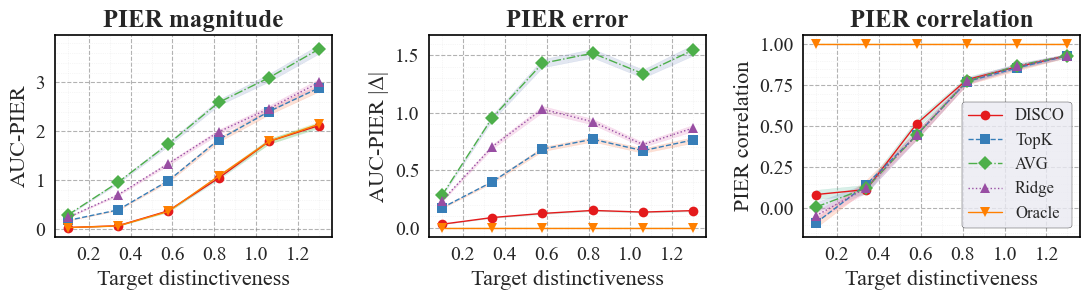

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker


plt.rcParams['font.family'] = 'Times New Roman'  # Global font

# === Define colors ===
base_methods = [m for m in METHOD_ORDER if m != "oracle"]

# Softer colors for fills (histograms, error bands)
fill_palette = sns.color_palette("Set2", n_colors=len(base_methods))

# Stronger colors for lines (sharper, higher contrast)
line_palette = sns.color_palette("Set1", n_colors=len(base_methods))

# Map methods consistently
color_map_fill = {m: c for m, c in zip(base_methods, fill_palette)}
color_map_line = {m: c for m, c in zip(base_methods, line_palette)}

# Special handling for "oracle"
if "oracle" in METHOD_ORDER:
    color_map_fill["oracle"] = (0.7, 0.7, 0.7)   # light gray fill
    color_map_line["oracle"] = (0.0, 0.0, 0.0)   # solid black line

# === Define line styles and markers ===
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'P', '*', 'X', 'h']

style_map = {}
for i, method in enumerate(METHOD_ORDER):
    style_map[method] = (
        linestyles[i % len(linestyles)],
        markers[i % len(markers)]
    )

# === Create subplots ===
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1), sharex=True)

metric_specs = [
    ('mean_auc',   'sem_auc',   'AUC-PIER', 'PIER magnitude'),
    ('mean_delta', 'sem_delta', 'AUC-PIER |Δ|', 'PIER error'),
    ('mean_corr',  'sem_corr',  'PIER correlation', 'PIER correlation'),
]

for idx, (ax, (mean_key, sem_key, y_label, title)) in enumerate(zip(axes, metric_specs)):
    ax.set_facecolor('white')

    # Frame (spines)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color('black')

    # Plot each method
    for method in METHOD_ORDER:
        data = summary[summary['method'] == method].sort_values('alpha_target')
        if data.empty:
            continue
        linestyle, marker = style_map[method]

        # Error band (behind)
        ax.fill_between(
            data['alpha_target'],
            data[mean_key] - data[sem_key],
            data[mean_key] + data[sem_key],
            color=color_map_fill[method],
            alpha=0.25,
            zorder=1
        )

        # Line (on top, sharp)
        ax.plot(
            data['alpha_target'],
            data[mean_key],
            marker=marker,
            markersize=7,
            linewidth=1.0,
            linestyle=linestyle,
            color=color_map_line[method],
            label=method,
            alpha=1.0,
            zorder=2
        )

    # Titles and labels
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xlabel('Target distinctiveness', fontsize=16)
    ax.set_ylabel(y_label, fontsize=16)
    ax.tick_params(axis='both', labelsize=14)

    # Macro and micro gridlines
    ax.grid(True, which='major', linestyle='--', linewidth=0.8, alpha=0.6, color='gray')
    ax.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.4, color='lightgray')
    ax.minorticks_on()

    # Denser x-ticks
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # Legend only in last subplot
    if idx == len(axes) - 1:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(
                handles, labels,
                fontsize=12, frameon=True,
                framealpha=0.8, edgecolor='black',
                loc='best'
            )


plt.tight_layout(h_pad=2.0, w_pad=2.0)

# Save high-quality figure
plt.savefig("../pictures/identifiability.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Next steps

- Increase SEEDS or N_QUERIES_PER_REPEAT to shrink error bars.
- Swap in pre-trained devices if you have stored models for reuse.
- Extend METHOD_ORDER or the intervention list to explore additional baselines.